# Fine-Tuning BERT model for Email Classification

## Libraries and load data

In [ ]:
!pip install datasets
!pip install evaluate
!pip install gradio
!pip install shap
!pip install lime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 11.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [ ]:
# import all necessary libraries
import torch
import pandas as pd
import numpy as np
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, pipeline
from datasets import Dataset
import re
import evaluate
from bs4 import BeautifulSoup
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from shap import Explanation
import gradio as gr
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
from wordcloud import WordCloud


In [ ]:
# load in the dataset
df = pd.read_csv("Enron.csv")

print(df.head())

                                      subject  \
0                   hpl nom for may 25 , 2001   
1            re : nom / actual vols for 24 th   
2  enron actuals for march 30 - april 1 , 201   
3                   hpl nom for may 30 , 2001   
4                   hpl nom for june 1 , 2001   

                                                body  label  
0  ( see attached file : hplno 525 . xls )\r\n- h...      0  
1  - - - - - - - - - - - - - - - - - - - - - - fo...      0  
2  estimated actuals\r\nmarch 30 , 2001\r\nno flo...      0  
3  ( see attached file : hplno 530 . xls )\r\n- h...      0  
4  ( see attached file : hplno 601 . xls )\r\n- h...      0  


## Clean function

In [ ]:
# There is no need to go through preprocessing for this dataset and the chosen LLM.
# for any dataset or email that contains HTML tags, this function may be useful
def clean_email_text(text):
    # remove HTML tags
    soup = BeautifulSoup(text, "html.parser")
    stripped_text = soup.get_text()

    # remove unnecessary empty space
    stripped_text = re.sub(r'\s+', ' ', stripped_text).strip()

    return stripped_text


## Model

In [ ]:
# load model and tokenizer
model_name = "bert-base-uncased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## Dataset

In [ ]:
# load raw dataset from pandas dataframe
pd_dataset = pd.DataFrame({"text": df["body"].tolist(),
                           "labels": df["label"].tolist()})
dataset = Dataset.from_pandas(pd_dataset)

## split the dataset into train, validation, and test dataset
# split into train and temp
split = dataset.train_test_split(test_size=0.2, seed=47)

# split temp into validation and test
temp_split = split['test'].train_test_split(test_size=0.5, seed=47)

# merge back everything into one dataset
final_dataset = {
    'train': split['train'],
    'validation': temp_split['train'],
    'test': temp_split['test']
}

##Exploratory Data Analysis

Text(0.5, 1.0, 'Percentage of clean/phishing emails')

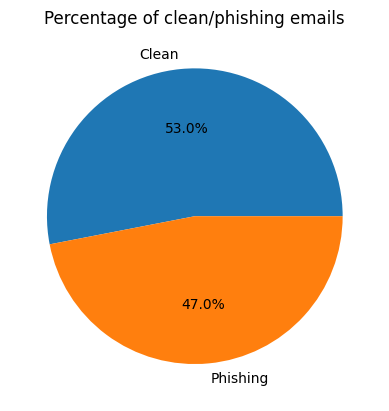

In [ ]:
# Creates a pie graph of the occurances of phishing and clean messages
plt.pie(pd_dataset['labels'].value_counts(), labels = ['Clean', 'Phishing'], autopct='%0.1f%%')
plt.title("Percentage of clean/phishing emails")

Top reoccurring text in clean emails:
1. hou ect
2. ect ect
3. will
4. _ _
5. enron enron
6. know
7. enron s
8. need
9. deal
10. said
11. may
12. pm
13. one
14. time
15. cc subject
16. original message
17. subject re
18. thank
19. ect cc
20. day




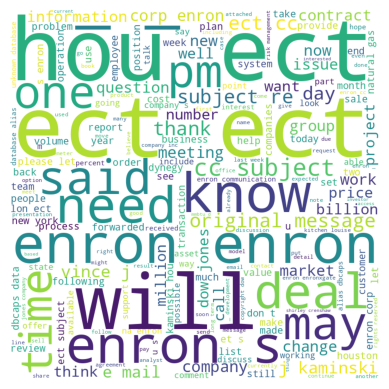

In [ ]:
# Creates a word cloud, showing how often do certain words appear in clean emails
wordcloud = WordCloud(width = 800, height = 800, background_color ='white', min_font_size = 10)
clean_wc = wordcloud.generate(pd_dataset[pd_dataset["labels"]==0]["text"].str.cat(sep = " "))
plt.axis("off")
plt.imshow(clean_wc)


# Prints the words that occur the most in clean emails
print("Top reoccurring text in clean emails:")
clean_words = list(wordcloud.words_.keys())
top20_clean_words = []
for key in range(20):
  top20_clean_words.append(clean_words[key])
  print(str(key+1) + ". " + clean_words[key])
print("\n")

Top reoccurring text in phishing emails:
1. _ _
2. will
3. company
4. one
5. time
6. e mail
7. money
8. make
9. report
10. email
11. now
12. thank
13. u
14. need
15. looking statement
16. want
17. use
18. message
19. product
20. order




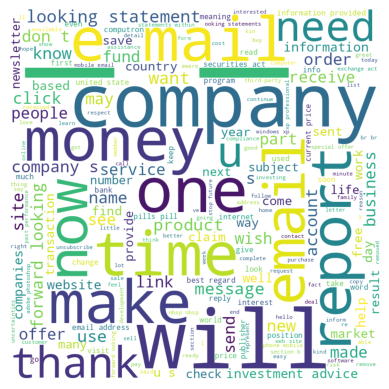

In [ ]:
# Creates a word cloud, showing how often do certain words appear in phishing emails
wordcloud = WordCloud(width = 800, height = 800, background_color ='white', min_font_size = 10)
phish_wc = wordcloud.generate(pd_dataset[pd_dataset["labels"]==1]["text"].str.cat(sep = " "))
plt.axis("off")
plt.imshow(phish_wc)


# Prints the words that occur the most in phishing emails
print("Top reoccurring text in phishing emails:")
phish_words = list(wordcloud.words_.keys())
top20_phish_words = []
for key in range(20):
  top20_phish_words.append(phish_words[key])
  print(str(key+1) + ". " + phish_words[key])
print("\n")

## Tokenize

In [ ]:
# tokenize_function to tokenize dataset
# tokenizes input text for MLM fine-tuning
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True, max_length=512)

# tokenize dataset
#The .map() tokenization only prepares the dataset—but does not return PyTorch tensors.
tokenized_datasets = {
    key: df.map(tokenize_function, batched=True)
    for key, df in final_dataset.items()
}

# data collator for padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/23813 [00:00<?, ? examples/s]

Map:   0%|          | 0/2977 [00:00<?, ? examples/s]

Map:   0%|          | 0/2977 [00:00<?, ? examples/s]

## Train

In [ ]:

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results", # where to save model and checkpoints
    eval_strategy="epoch", # run evaluation every epoch
    save_strategy="epoch", # save checkpoints after every epoch
    logging_strategy="epoch", # log metrics every epoch
    learning_rate=2e-5, # bert model is already pre-trained on massive data and do not want to override everything when updating weights; generally 2e-5 to 5e-5 is used when fine-tuning BERT model to avoid overfitting; lower rate is generally used for smaller datasets
    per_device_train_batch_size=8, # had to reduce to 8 from 16 because my laptop could not handle
    per_device_eval_batch_size=8, # had to reduce to 8 from 16 because my laptop could not handle
    num_train_epochs=5, # too many epochs can lead to overfitting
    weight_decay=0.01, # regularization -> prevent overfitting
    load_best_model_at_end=True, # automatically keeps the best checkpoint based on accuracy
    metric_for_best_model="accuracy" # sets which metric to revert back to
)


# way to keep track of accuracy of each training epoch source:
# https://github.com/huggingface/notebooks/blob/main/examples/text_classification.ipynb
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

C:\Users\kyung\AppData\Local\Temp\ipykernel_19064\2764885924.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# train the model
trainer.train()

# save the fine-tuned model
trainer.save_model("./email_classifier_bert")
tokenizer.save_pretrained("./email_classifier_bert")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.074300,0.038721,0.990259
2,0.014600,0.105445,0.978502
3,0.007900,0.034956,0.993954
4,0.002500,0.036611,0.994625
5,0.000600,0.042988,0.994961


('./email_classifier_bert\\tokenizer_config.json',
 './email_classifier_bert\\special_tokens_map.json',
 './email_classifier_bert\\vocab.txt',
 './email_classifier_bert\\added_tokens.json',
 './email_classifier_bert\\tokenizer.json')

Training loss is steadily going down -> meaning the model is continuing to learn from the training data.  
Validation Loss dipped at 2nd epoch but stayed stable afterward -> sign of brief overfitting or could have been a noisy batch of data but was recovered in epoch 3.   
=> no signs of severe overfitting.

## EVAL

In [ ]:
# load fine-tuned DistilBERT model and tokenizer
model_path = "./email_classifier_bert"
cf_tokenizer = AutoTokenizer.from_pretrained(model_path)
cf = AutoModelForSequenceClassification.from_pretrained(model_path)
cf.eval()  # set model to evaluation mode

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
# create new trainer with fine-tuned model
test_trainer = Trainer(
    model=cf,
    tokenizer=cf_tokenizer,
)

# evaluate on test set and run predictions for classification report
metrics = test_trainer.evaluate(tokenized_datasets["test"])
print("Test Set Metrics:", metrics)
pred_output = test_trainer.predict(tokenized_datasets["test"])
preds = np.argmax(pred_output.predictions, axis=1)
email_labels = pred_output.label_ids

C:\Users\kyung\AppData\Local\Temp\ipykernel_9836\3417932165.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  test_trainer = Trainer(


Test Set Metrics: {'eval_loss': 0.027882538735866547, 'eval_model_preparation_time': 0.003, 'eval_runtime': 806.8434, 'eval_samples_per_second': 3.69, 'eval_steps_per_second': 0.462}


## Classification Report, Confusion Matrix, ROC-AUC

In [ ]:
# classification report
model_cr = classification_report(email_labels, preds, target_names=["legit", "phishing"])
print(model_cr)

              precision    recall  f1-score   support

       legit       1.00      1.00      1.00      1574
    phishing       1.00      1.00      1.00      1403

    accuracy                           1.00      2977
   macro avg       1.00      1.00      1.00      2977
weighted avg       1.00      1.00      1.00      2977



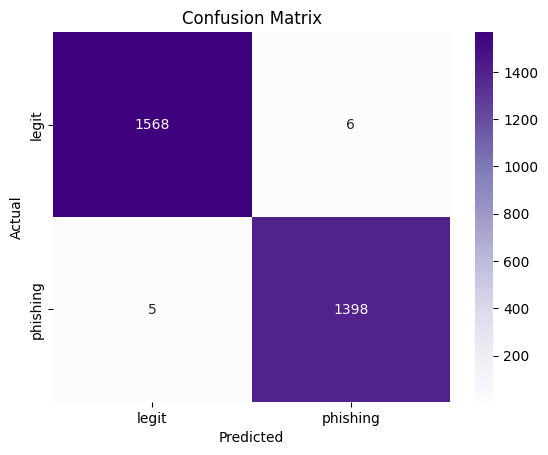

In [ ]:
# confusion matrix
model_cm = confusion_matrix(email_labels, preds)

# visualize the confusion matrix
sns.heatmap(model_cm, annot=True, fmt="d", cmap="Purples", xticklabels=["legit", "phishing"], yticklabels=["legit", "phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


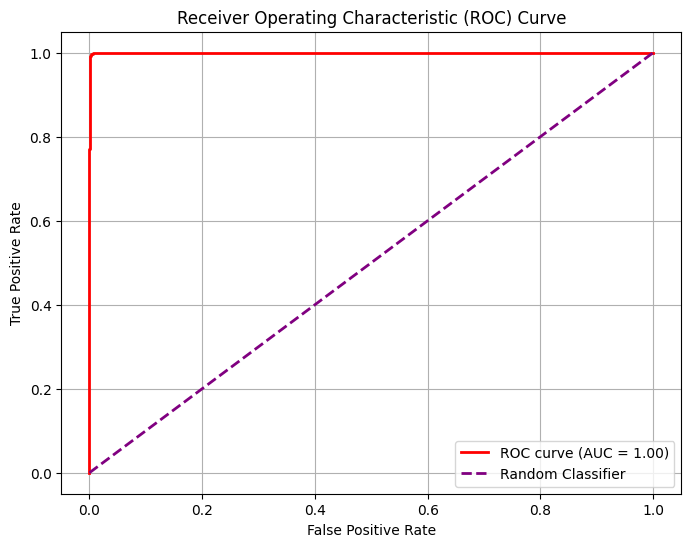

In [ ]:
# source: https://www.w3schools.com/python/python_ml_auc_roc.asp

# get predicted probabilities for the positive class (phishing = 1)
probs = pred_output.predictions
probs = [p[1] for p in probs]  # index 1 = positive class probability

# true labels
true_labels = pred_output.label_ids

# compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(true_labels, probs)
roc_auc = auc(fpr, tpr)

# plot the ROC curve and AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="red", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="purple", lw=2, linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## SHAP

In [ ]:
# pull body texts of emails from the test dataset
body_texts = final_dataset["test"]["text"]

# correctly classified legit emails
correct_legit = [i for i, (pred, label) in enumerate(zip(preds, email_labels)) if pred == label == 0]

# correctly classified phishing emails
correct_phish = [i for i, (pred, label) in enumerate(zip(preds, email_labels)) if pred == label == 1]

# extract body_texts from each classification
correct_legit_body = [body_texts[i] for i in correct_legit]
correct_phish_body = [body_texts[i] for i in correct_phish]


In [ ]:
print(correct_legit_body[2])

dr . bill mcmullen called you this morning and said that you had called
the school last week asking for courses that they scheduled for quantitive
analysis .
they gave your name to dr . mcmullen and he would like you to email
him exactly what you are looking for .
his email address is : mcmullew @ tamug . tamu . edu
thanks !
shirley


In [ ]:
print(correct_phish_body[20])

its illegal to use hacked windows xp
leading software such as :
windows x * p professional + office x ' p professi 0 nal for as low as 8 o do | | ars
more here . . . : http : / / pennyroyal . xpforyou . com /
the offer is valid till december 29 th
the stock is limited
your password has expired
sheri benitez
attorneyatlaw
ischemia technologies , inc . , arvada , 80003 , united states of america
phone : 146 - 287 - 7371
mobile : 747 - 422 - 3114
email : yvdjjw @ dx . net
your reply to this confirmation message is not needed
this shareware is a 50 day trial shareware
notes :
the contents of this message is for information and should not be dragonhead caraway
trypsin vehicle guidebook
time : fri , 24 dec 2004 01 : 29 : 01 - 0500


In [ ]:
# source: https://shap.readthedocs.io/en/latest/example_notebooks/text_examples/sentiment_analysis/Emotion%20classification%20multiclass%20example.html

pipe = pipeline("text-classification", model=cf, tokenizer=cf_tokenizer, return_all_scores=True)
masker = shap.maskers.Text(tokenizer=cf_tokenizer) # make SHAP use the tokenizer from the fine-tuned model
explainer=shap.Explainer(pipe)

Device set to use cpu
c:\Users\kyung\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
legit_example = clean_email_text(correct_legit_body[2])
phish_example = clean_email_text(correct_phish_body[20])

In [ ]:
shap_values_legit = explainer([legit_example])
shap_values_phish = explainer([phish_example])

PartitionExplainer explainer: 2it [00:46, 46.39s/it]               
PartitionExplainer explainer: 2it [01:09, 69.60s/it]               


In [ ]:
exp = explainer([legit_example])[0]
for name, val in zip(exp.feature_names, exp.data):
    print(f"{name =}, {val = }")

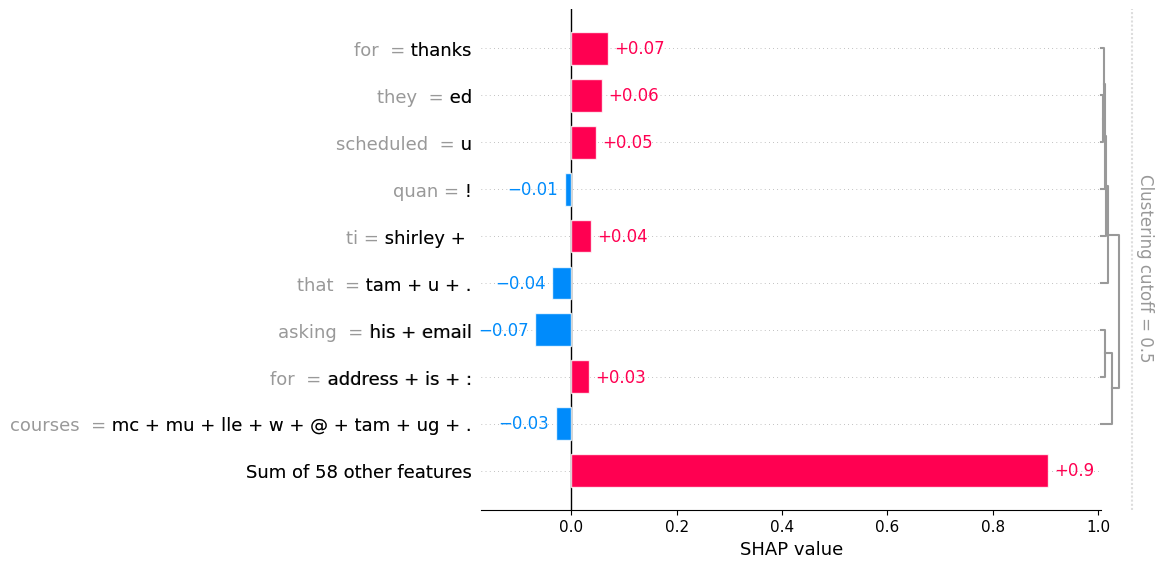

In [ ]:
# SHAP values per token for 1 "legit" email
shap.plots.bar(shap_values_legit[0, :, 0])

In [ ]:
shap.plots.bar(shap_values_phish[0, :, 1])

IndexError: string index out of range

This mis-alignment of feature_value = feature_name happens because the tokenization by the model and SHAP is different and it produces different number of tokens.  
This problem is common with LLM models like BERT.
SHAP was initially designed for tabular data and struggles with LLM models

## LIME

In [ ]:
def predict_prob(texts):
    tokens = cf_tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    with torch.no_grad():
        outputs = cf(**tokens)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    return probs.numpy()


In [ ]:
class_names = ["legit", "phishing"]
explainer = LimeTextExplainer(class_names=class_names)

explanation = explainer.explain_instance(legit_example, predict_prob, num_features=20)

In [ ]:
# display using matplot
fig = explanation.as_pyplot_figure()
fig.show()

NameError: name 'explainer' is not defined

In [ ]:
explanation = explainer.explain_instance(phish_example, predict_prob, num_features=10)
explanation.show_in_notebook(text=True)

## gradio showcase

In [ ]:
# define a label map
label_map = {0: "legit", 1: "phishing"}

# define a function for showcase
def predict(text):
    # tokenize input text
    inputs = cf_tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # run inference; disable gradient computation for faster performance
    with torch.no_grad():
        outputs = cf(**inputs)

    # get logits and convert to predicted class
    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=-1).item()

    return label_map[predicted_class]  # returns if the email is legit for phishing

# define function to display the email classification
def display_classification(text):
    text = clean_email_text(text)
    predicted_label = predict(text)
    return f"Predicted Label: {predicted_label}"

In [ ]:
# Simple Gradio UI
iface = gr.Interface(
    fn=display_classification,
    inputs=gr.Textbox(lines=15, placeholder="Paste an email body here..."),
    outputs="text",
    title="Email Phishing Classifier",
    description="Paste an email body below. The model will predict whether it's legit or phishing."
)

iface.launch()


ERROR:    Traceback (most recent call last):
  File "c:\Users\kyung\AppData\Local\Programs\Python\Python311\Lib\asyncio\runners.py", line 190, in run
    return runner.run(main)
           ^^^^^^^^^^^^^^^^
  File "c:\Users\kyung\AppData\Local\Programs\Python\Python311\Lib\asyncio\runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kyung\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py", line 641, in run_until_complete
    self.run_forever()
  File "c:\Users\kyung\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py", line 608, in run_forever
    self._run_once()
  File "c:\Users\kyung\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py", line 1898, in _run_once
    event_list = self._selector.select(timeout)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kyung\AppData\Local\Programs\Python\Python311\Lib\selectors.py", line 323, in sel